In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sleppyfish/aircraft-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'aircraft-classification-dataset' dataset.
Path to dataset files: /kaggle/input/aircraft-classification-dataset
Contents of base_path (/kaggle/input):
['aircraft-classification-dataset']
Contents of path (/kaggle/input/aircraft-classification-dataset):
['test', 'train']


### Dataset Overview

Let's examine the structure of the downloaded dataset and display some sample images from the `train` and `test` directories.

In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'test'))}")

Contents of the 'train' directory: ['7', '2', '5', '8', '3', '1', '4', '9', '6']
Contents of the 'test' directory: ['7', '2', '5', '8', '3', '1', '4', '9', '6']


### Displaying Sample Images

Now, let's visualize a few sample images from the 'train' and 'test' datasets to get a better understanding of the image content.


--- Sample Images from Training Dataset (/kaggle/input/aircraft-classification-dataset/train) ---
Found 19569 images in /kaggle/input/aircraft-classification-dataset/train. Displaying 6 samples:


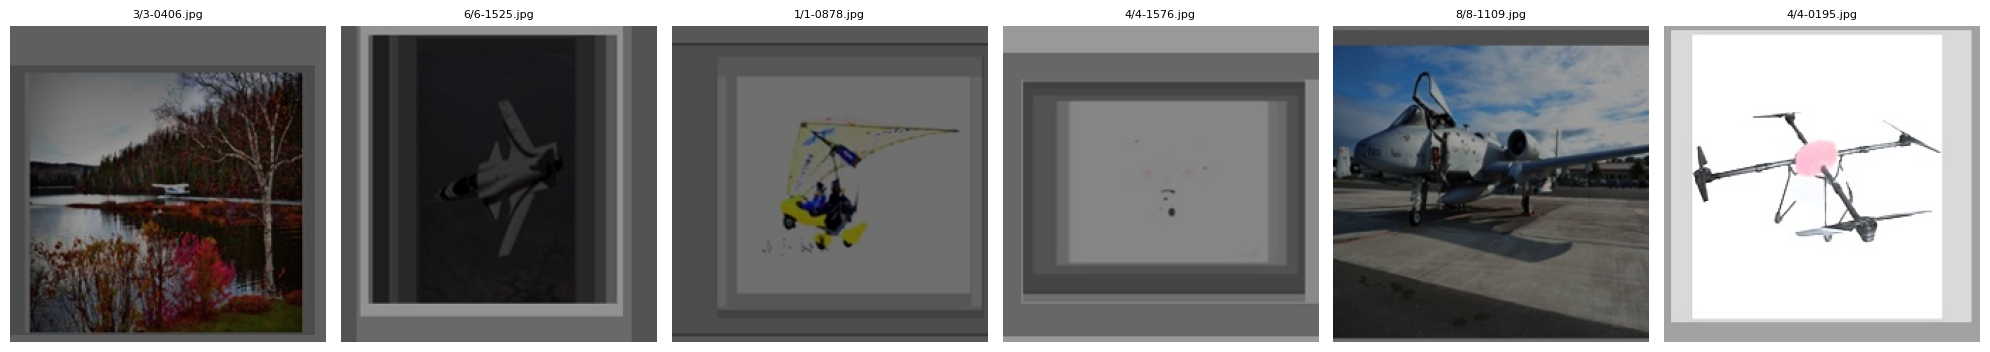


--- Sample Images from Test Dataset (/kaggle/input/aircraft-classification-dataset/test) ---
Found 2305 images in /kaggle/input/aircraft-classification-dataset/test. Displaying 6 samples:


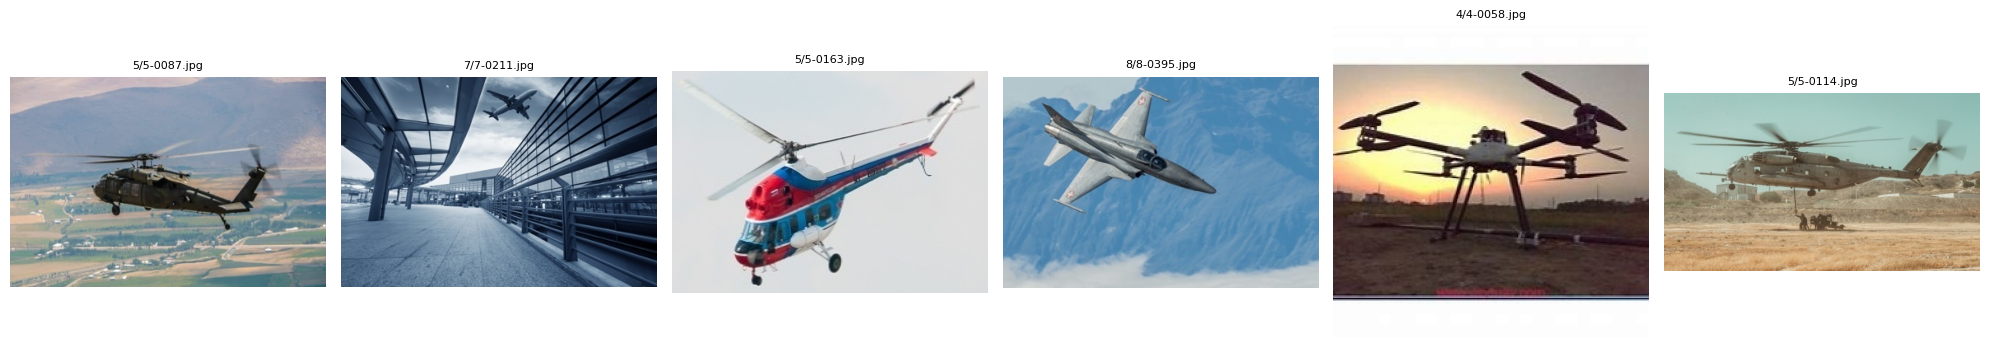

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig) # Close empty figure if no samples
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Display sample images from the 'train' directory
train_path = os.path.join(path, 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

# Display sample images from the 'test' directory
test_path = os.path.join(path, 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

### GPU Availability Check
Before starting the training process, let's ensure that the GPU is properly detected by TensorFlow.

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

# List physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

TensorFlow version: 2.20.0
Found GPU at: /device:GPU:0
Num GPUs Available:  1


### Data Preprocessing and Model Construction
We will use `ImageDataGenerator` for normalization and loading. Then, we build a MobileNet model with transfer learning.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Prepare Data Generators
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 2. Build MobileNet Model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# FIXED: Changed 'categorical_loss' to 'categorical_crossentropy'
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Train the Model
print("Starting training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)

Found 15657 images belonging to 9 classes.
Found 3912 images belonging to 9 classes.
Starting training...
Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 98s 169ms/step - accuracy: 0.8939 - loss: 0.3135 - val_accuracy: 0.8901 - val_loss: 0.3301
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.9647 - loss: 0.1047 - val_accuracy: 0.8796 - val_loss: 0.4285
Epoch 3/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 34s 69ms/step - accuracy: 0.9810 - loss: 0.0573 - val_accuracy: 0.9363 - val_loss: 0.2108
Epoch 4/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - accuracy: 0.9818 - loss: 0.0516 - val_accuracy: 0.8962 - val_loss: 0.3824
Epoch 5/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.9842 - loss: 0.0471 - val_accuracy: 0.9282 - val_loss: 0.3440
Epoch 6/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.9867 - loss: 0.0359 - val_accuracy: 0.8934 - val_loss: 0.5256
Epoch 7/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 32s 66ms/step - accuracy: 0.9953 - loss: 0.0142 - val_accuracy: 0.9277 - 

### Training Results Summary
Evaluating the model on the test set and printing final metrics.

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Found 2305 images belonging to 9 classes.
73/73 ━━━━━━━━━━━━━━━━━━━━ 17s 235ms/step - accuracy: 0.9132 - loss: 0.7756
Test Loss: 0.7756
Test Accuracy: 0.9132


### Training Performance Visualization
Visualizing the Accuracy and Loss curves over epochs.

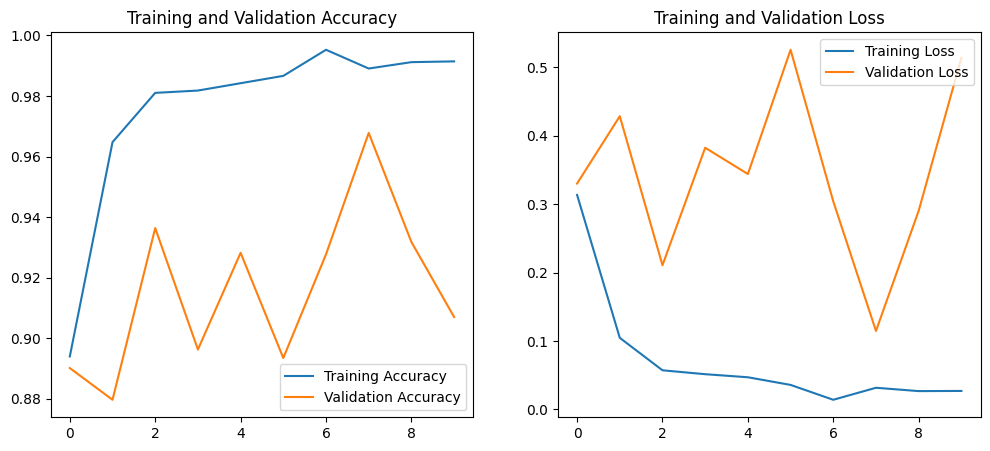

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')
    plt.show()

plot_history(history)